In [1]:
# STEP 1 — IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
# STEP 2 — LOAD DATASET

In [4]:
df = pd.read_csv("heart_disease.csv")

In [5]:
# STEP 3 — DISPLAY FIRST 5 ROWS

In [6]:
print(df.head())

    Age  Gender  Blood Pressure  Cholesterol Level Exercise Habits Smoking  \
0  56.0    Male           153.0              155.0            High     Yes   
1  69.0  Female           146.0              286.0            High      No   
2  46.0    Male           126.0              216.0             Low      No   
3  32.0  Female           122.0              293.0            High     Yes   
4  60.0    Male           166.0              242.0             Low     Yes   

  Family Heart Disease Diabetes        BMI High Blood Pressure  ...  \
0                  Yes       No  24.991591                 Yes  ...   
1                  Yes      Yes  25.221799                  No  ...   
2                   No       No  29.855447                  No  ...   
3                  Yes       No  24.130477                 Yes  ...   
4                  Yes      Yes  20.486289                 Yes  ...   

  High LDL Cholesterol Alcohol Consumption Stress Level Sleep Hours  \
0                   No           

In [7]:
# STEP 4 — CHECK COLUMN NAMES

In [8]:
print(df.columns)

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='object')


In [9]:
# STEP 5 — REMOVE EXTRA SPACES

In [10]:
df.columns = df.columns.str.strip()

In [11]:
# STEP 6 — CHECK DATASET INFORMATION

In [12]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

In [13]:
# STEP 7 — CHECK MISSING VALUES

In [14]:
print(df.isnull().sum())


Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64


In [15]:
# STEP 8 — FILL MISSING VALUES

In [16]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [17]:
# STEP 9 — CHECK DUPLICATE VALUES

In [18]:
print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicate Rows: 0


In [19]:
# STEP 10 — ENCODE CATEGORICAL DATA

In [20]:
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [21]:
# STEP 11 — DISPLAY CLEANED DATA

In [22]:
print(df.head())

    Age  Gender  Blood Pressure  Cholesterol Level  Exercise Habits  Smoking  \
0  56.0       1           153.0              155.0                0        1   
1  69.0       0           146.0              286.0                0        0   
2  46.0       1           126.0              216.0                1        0   
3  32.0       0           122.0              293.0                0        1   
4  60.0       1           166.0              242.0                1        1   

   Family Heart Disease  Diabetes        BMI  High Blood Pressure  ...  \
0                     1         0  24.991591                    1  ...   
1                     1         1  25.221799                    0  ...   
2                     0         0  29.855447                    0  ...   
3                     1         0  24.130477                    1  ...   
4                     1         1  20.486289                    1  ...   

   High LDL Cholesterol  Alcohol Consumption  Stress Level  Sleep Hours  \

In [23]:
# STEP 12 — STATISTICAL SUMMARY

In [24]:
print(df.describe())

                Age       Gender  Blood Pressure  Cholesterol Level  \
count  10000.000000  10000.00000    10000.000000       10000.000000   
mean      49.296259      0.50220      149.757740         225.425577   
std       18.167567      0.50002       17.556265          43.510390   
min       18.000000      0.00000      120.000000         150.000000   
25%       34.000000      0.00000      134.000000         187.000000   
50%       49.000000      1.00000      150.000000         225.425577   
75%       65.000000      1.00000      165.000000         263.000000   
max       80.000000      1.00000      180.000000         300.000000   

       Exercise Habits       Smoking  Family Heart Disease      Diabetes  \
count      10000.00000  10000.000000          10000.000000  10000.000000   
mean           0.99350      0.514800              0.497500      0.495200   
std            0.82032      0.499806              0.500019      0.500002   
min            0.00000      0.000000              0.0000

In [25]:
# STEP 13 — CORRELATION HEATMAP

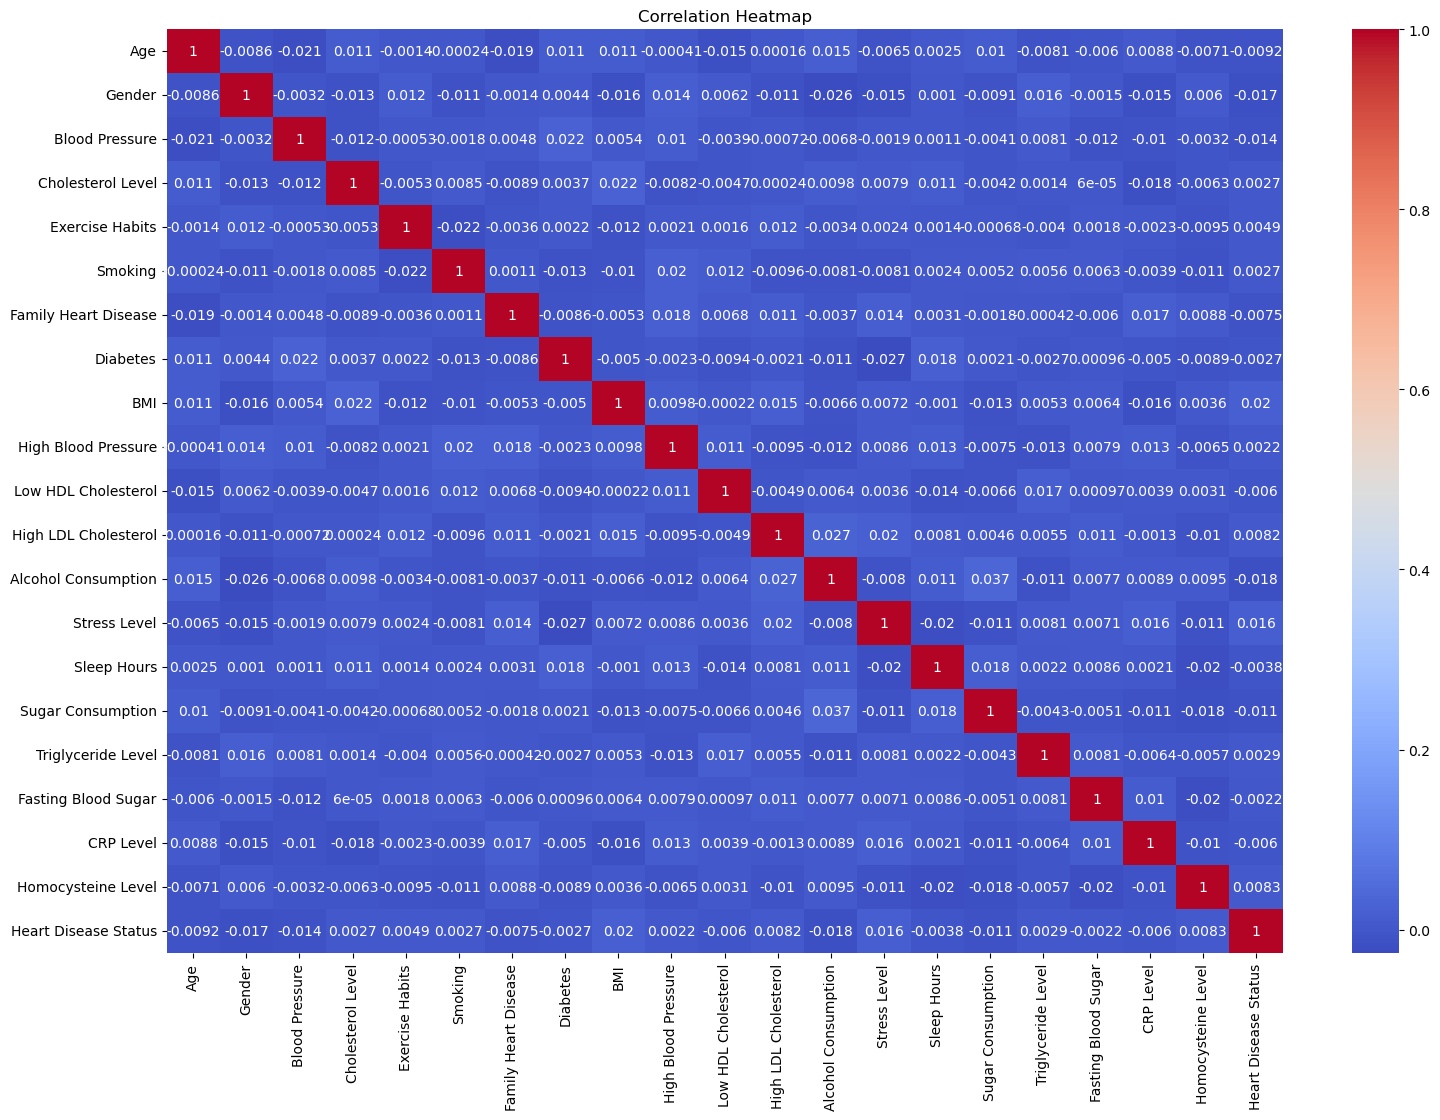

In [26]:
plt.figure(figsize=(18,12))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()


In [27]:
# STEP 14 — HEART DISEASE COUNT

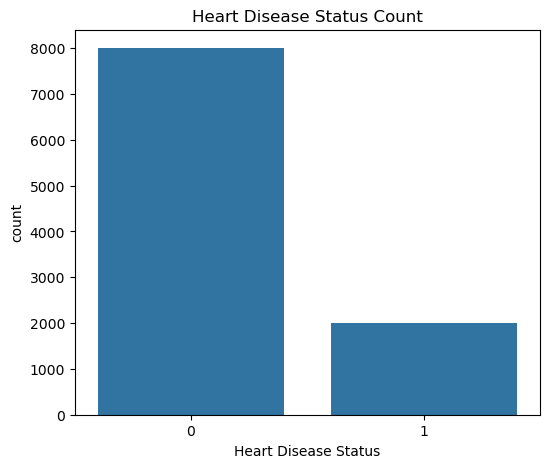

In [28]:
plt.figure(figsize=(6,5))

sns.countplot(x='Heart Disease Status', data=df)

plt.title("Heart Disease Status Count")

plt.show()


In [29]:
# STEP 15 — AGE DISTRIBUTION

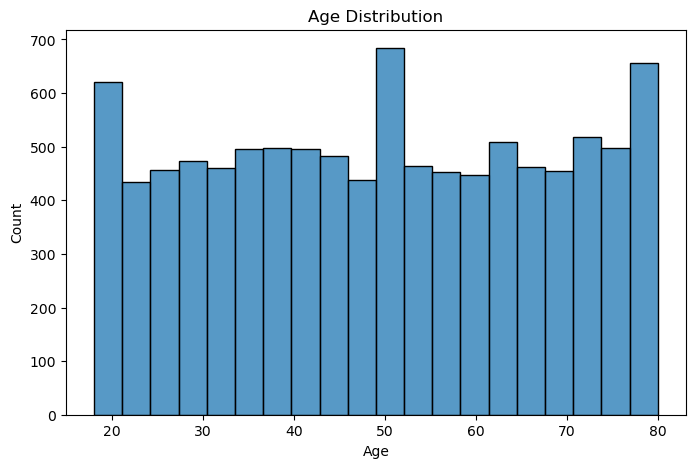

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20)

plt.title("Age Distribution")

plt.show()

In [31]:
# STEP 16 — CHOLESTEROL VS HEART DISEASE

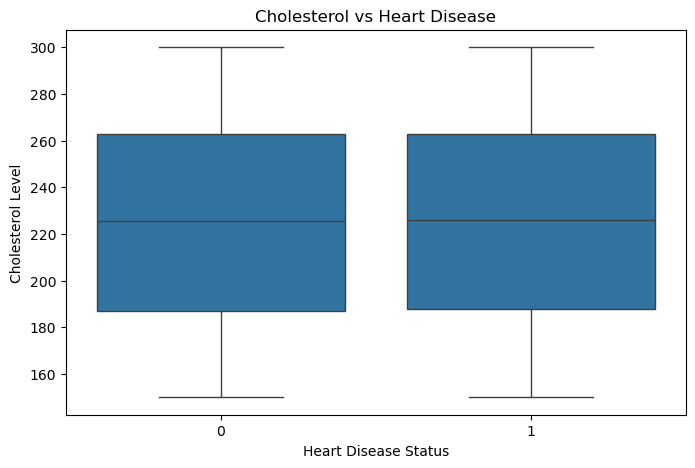

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Heart Disease Status',
    y='Cholesterol Level',
    data=df
)

plt.title("Cholesterol vs Heart Disease")

plt.show()

In [33]:
# STEP 17 — DEFINE FEATURES AND TARGET

In [34]:
X = df.drop('Heart Disease Status', axis=1)

y = df['Heart Disease Status']

In [35]:
# STEP 18 — SPLIT TRAINING AND TESTING DATA

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [37]:
# STEP 19 — TRAIN RANDOM FOREST MODEL

In [38]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
# STEP 20 — MAKE PREDICTIONS

In [40]:
predictions = model.predict(X_test)

In [41]:
# STEP 21 — MODEL ACCURACY

In [42]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8065


In [43]:
# STEP 22 — CLASSIFICATION REPORT

In [45]:
print(classification_report(y_test, predictions, zero_division=0))

              precision    recall  f1-score   support

           0       0.81      1.00      0.89      1613
           1       0.00      0.00      0.00       387

    accuracy                           0.81      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.65      0.81      0.72      2000



In [46]:
# STEP 23 — CONFUSION MATRIX

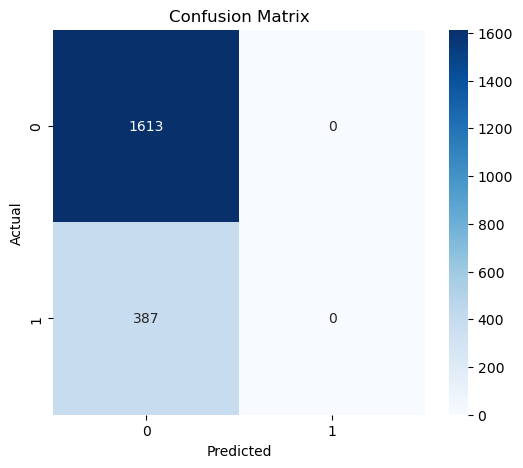

In [47]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


In [48]:
# STEP 24 — FEATURE IMPORTANCE

In [49]:
importance = model.feature_importances_

feature_names = X.columns

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)


                 Feature  Importance
14           Sleep Hours    0.099329
8                    BMI    0.097651
19    Homocysteine Level    0.097542
18             CRP Level    0.096030
16    Triglyceride Level    0.090631
3      Cholesterol Level    0.086382
17   Fasting Blood Sugar    0.083156
0                    Age    0.081992
2         Blood Pressure    0.080169
4        Exercise Habits    0.023054
15     Sugar Consumption    0.021959
13          Stress Level    0.021895
12   Alcohol Consumption    0.021464
7               Diabetes    0.014577
6   Family Heart Disease    0.014558
10   Low HDL Cholesterol    0.014414
11  High LDL Cholesterol    0.014191
9    High Blood Pressure    0.013924
5                Smoking    0.013817
1                 Gender    0.013265


In [50]:
# STEP 25 — FEATURE IMPORTANCE GRAPH

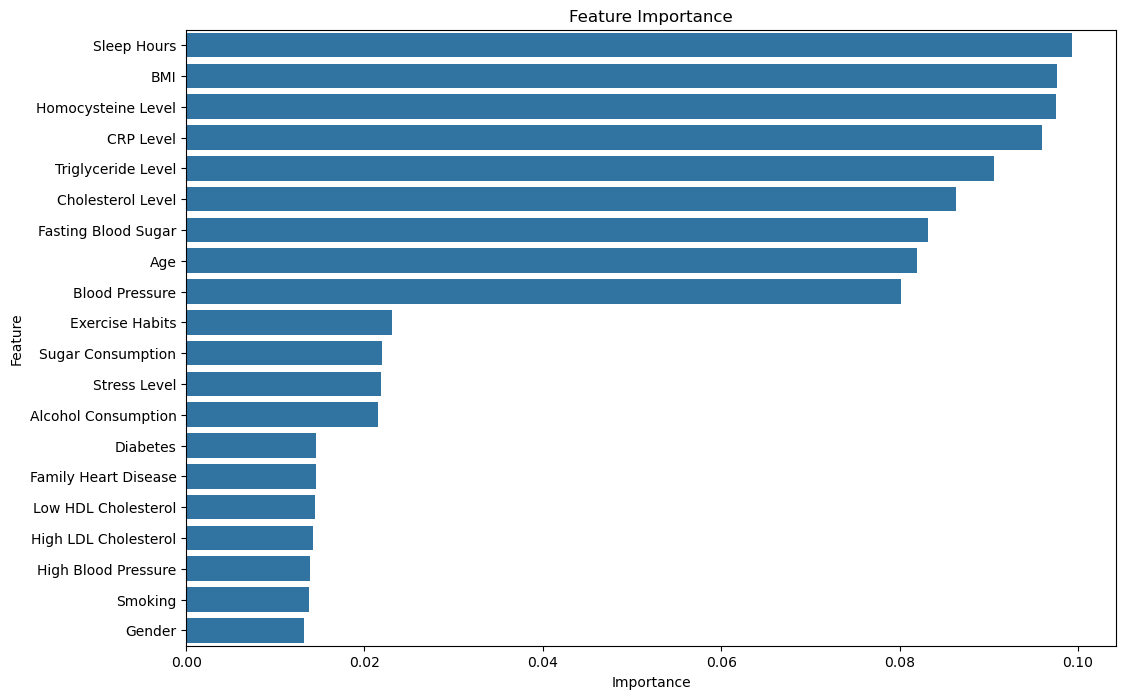

In [51]:
plt.figure(figsize=(12,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

In [ ]:
# PROJECT COMPLETED